Задание 3:
У вас есть архив с данными по производству электроэнергии ветряными мельницами в Германии. Вам необходимо исследовать временной ряд, описать основные статистики для временного ряда, сделать вывод по временному ряду и сформировать исследовательский отчет подкрепленный соответствующими выводами. 

Необходимо выбрать модель для прогноза временного ряда, объяснить почему именно была выбрана данная модель, объяснить на каком основании. Сделайте прогноз по производству электроэнергии на 1 год вперед, измерить метрику качества. Оформить исследование в jupyter notebook’e.

Без отчета с подкрепленными выводами задание считается проваленным (то есть ноутбук с кодом и картинками мне не присылать).

Итоговая оценка за правильное и качественно выполненное задание 4 балла. 


Для попытки прогнозирования производства энергии использовалась SARIMA, так как присутствует сезонность

In [30]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm # for SARIMAX algorith
import warnings

sns.set()
%matplotlib inline
warnings.filterwarnings("ignore")

In [32]:
data = pd.read_csv("D:/DS_2025/9/homework/data.csv", parse_dates=['dt'],index_col=['dt'])

In [34]:
data

,MW
dt,
2011-01-01 00:00:00,3416.00
2011-01-01 00:15:00,4755.00
2011-01-01 00:30:00,4939.00
2011-01-01 00:45:00,4939.00
2011-01-01 01:00:00,4998.00
...,...
2021-12-30 06:45:00,8140.31
2021-12-30 07:00:00,8162.33
2021-12-30 07:15:00,8405.11


In [36]:
data1 = data ['2020-01-01 00:00:00':]

In [38]:
data1.shape

(70016, 1)

Столбец «dt» — это столбец даты, поэтому импортируем его как таковой, а затем установим его как дату и время

In [41]:
data1.index = pd.to_datetime(data1.index)

In [43]:
data1

,MW
dt,
2020-01-01 00:00:00,4271.92
2020-01-01 00:15:00,4194.67
2020-01-01 00:30:00,4090.77
2020-01-01 00:45:00,4181.72
2020-01-01 01:00:00,4301.05
...,...
2021-12-30 06:45:00,8140.31
2021-12-30 07:00:00,8162.33
2021-12-30 07:15:00,8405.11


In [45]:
#просмотр отсутствующих значений
data1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70016 entries, 2020-01-01 00:00:00 to 2021-12-30 07:45:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MW      70016 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


Смотрим на распределение признака

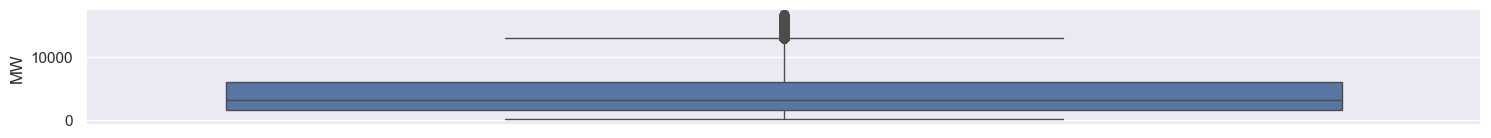

In [48]:
fig,ax = plt.subplots(figsize=(18,1.5))
sns.boxplot(data=data1.MW) 
plt.show()

Смотрим пропуски в датасете

In [51]:
data1.isna().sum()

MW    0
dtype: int64

По графику видим ежегодное увеличение производства эл энергии 

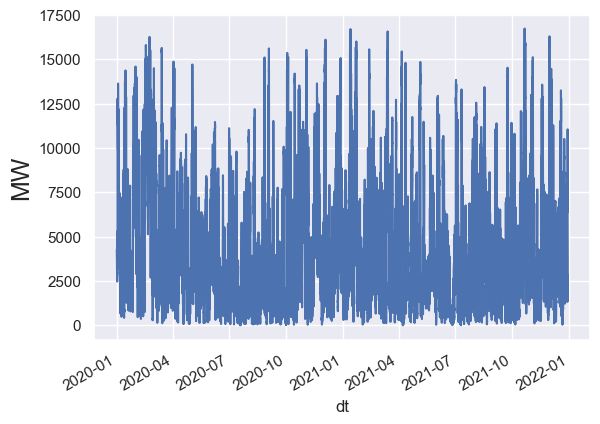

In [55]:
data1['MW'].plot()
plt.ylabel('MW', fontsize=18)
plt.show()

Из среднемесячных данных вырисовывается закономерность: увеличение в конце и начале года, в средине года производство идет на спад

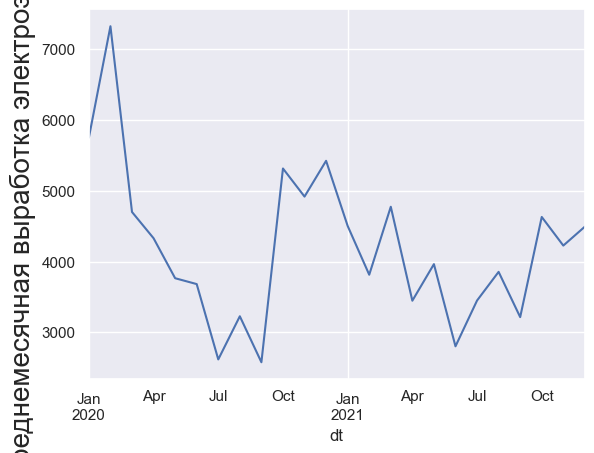

In [58]:
data1['MW'].resample('M').mean().plot()
plt.ylabel('Среднемесячная выработка электроэнергии', fontsize=20)
plt.show()

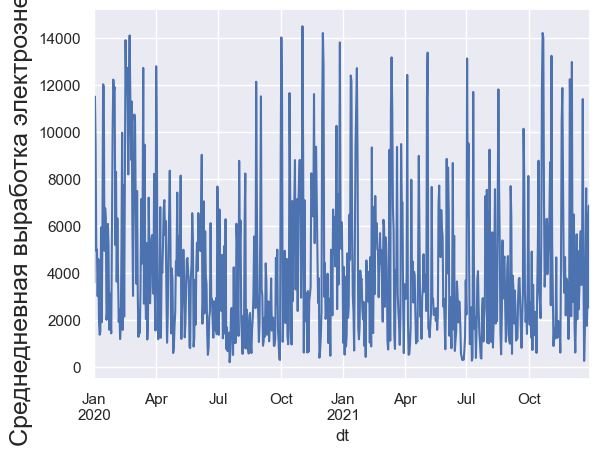

In [61]:

data1['MW'].resample('D').mean().plot()
plt.ylabel('Среднедневная выработка электроэнергии', fontsize=18)
plt.show()

Для прогноза мощности необходимо долгосрочное прогнозирование ветра. Таким образом, на основе данных за 2 года следует спрогнозировать производство энергии.¶


На графике видно, что минимум выбабатывается энергии в июне, июле и августе для генерации электроэнергии и ветра  методы временных рядов.

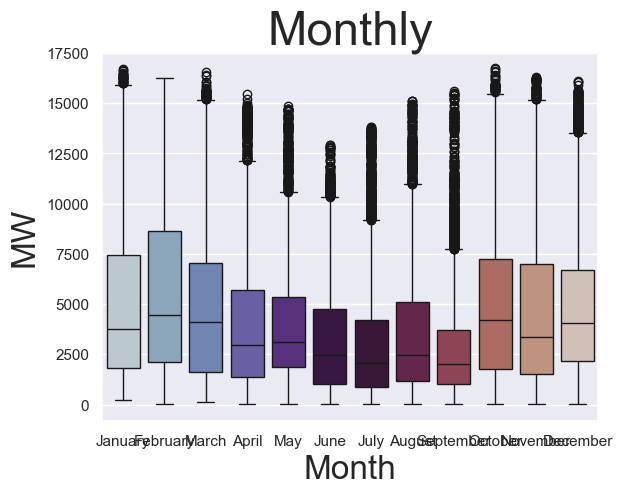

In [66]:

sns.boxplot(x=data1.index.month_name(), y='MW', data=data1, palette="twilight")
plt.ylabel('MW', fontsize=24)
plt.xlabel('Month', fontsize=24)
plt.title("Monthly", fontsize=34)
plt.show()

График почасовой выработки электроэнергии - показывает, что ночью вырабатывается энергии больше, чем днем

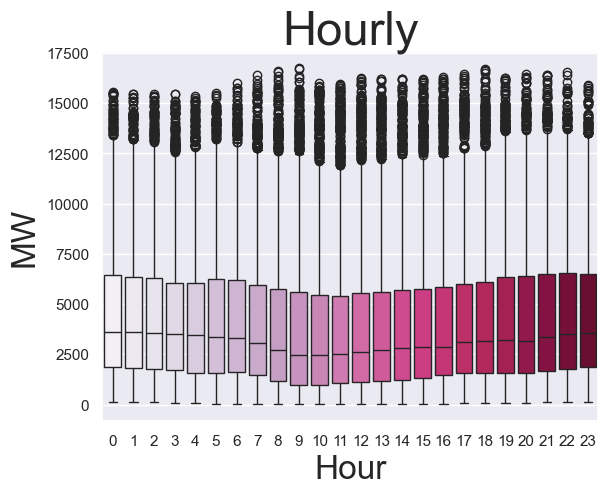

In [70]:
sns.boxplot(x=data1.index.hour, y='MW', data=data1, palette="PuRd")
plt.ylabel('MW', fontsize=24)
plt.xlabel('Hour', fontsize=24)
plt.title("Hourly", fontsize=34)
plt.show()

Поскольку графики выше показывают сезонный компонент, простую модель ARIMA использовать нельзя, но можно использовать сезонную ARIMA или SARIMA. Другим условием для SARIMA является то, что она одномерна, поэтому рассматриваем только скорость ветра для выходной мощности. Модель SARIMA использует те же 3 элемента ARIMA, плюс 4 дополнительных сезонных переменных

Выполняем проверку на стационарность

In [74]:
# Dicker-Fuller test
dftest = adfuller(data1.MW, autolag = 'AIC')
print(" ADF : ",dftest[0])
print(" p-Value : ", dftest[1])
print(" Num Of Lags : ", dftest[2])
print(" Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print(" Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

 ADF :  -19.939928254384085
 p-Value :  0.0
 Num Of Lags :  14
 Num Of Observations Used For ADF Regression and Critical Values Calculation : 70001
 Critical Values :
	 1% :  -3.4304434206627445
	 5% :  -2.861581290274325
	 10% :  -2.5667919774021515


p-Value :  0.0 - Можно сказать, что ряд стационарный

Значения каждого из требуемых параметров p,d,q, P,D,Q и m можно вычислить с помощью функции auto_arima. Однако, поскольку она стационарна, значение d равно 0

Переведем данные на ежедневные, поскольку пытаемся предсказать — объем вырабатываемой электроэнергии за следующие 365 дней

In [76]:
df_daily  = data1['MW'].resample('D').mean()
df_daily.dropna(inplace=True) 

In [78]:
len(df_daily)

730

Дополнительные доказательства сезонного характера набора данных можно увидеть, используя функцию сезонной декомпозиции и установив период = 21 (месяц)

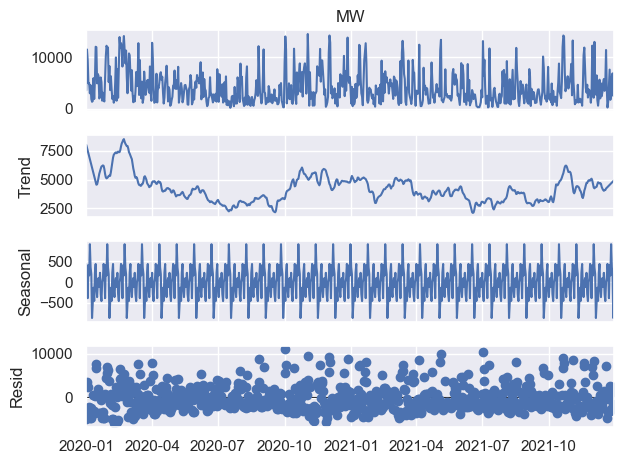

In [81]:
# разложим на сезон/тренд/остатки
result = seasonal_decompose(df_daily.dropna(), period=24, model='additive',extrapolate_trend=True)
result.plot()
plt.show()

In [83]:
model=pm.auto_arima(df_daily,start_p=0,d=0,start_q=0,
          max_p=15,max_q=5, 
          start_P=0,D=0, start_Q=0, 
          max_P=8, max_Q=8, 
          m=12, seasonal=True, stationary=True,
          error_action='warn',trace=True,
          supress_warnings=True,stepwise=True,
          random_state=20,n_fits=100)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=13850.914, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=13713.244, Time=0.26 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=13740.546, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=14585.640, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=13712.743, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=13712.930, Time=0.16 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=13714.924, Time=0.45 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=13714.256, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=13714.412, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=13737.616, Time=0.17 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=13716.243, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=13881.254, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[12] intercept
Total fit time: 1.505 seconds


In [85]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  730
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -6853.371
Date:                Tue, 29 Apr 2025   AIC                          13712.743
Time:                        23:49:04   BIC                          13726.522
Sample:                    01-01-2020   HQIC                         13718.059
                         - 12-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2445.7801    225.882     10.828      0.000    2003.060    2888.500
ar.L1          0.4181      0.031     13.436      0.000       0.357       0.479
sigma2      8.365e+06   4.71e+05     17.751      0.000    7.44e+06    9.29e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               146.09
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):               1.08   Skew:                             1.00
Prob(H) (two-sided):                  0.54   Kurtosis:                         3.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [87]:
p = 1
d = 0
q = 0
P = 0
D = 0
Q = 0
m = 12

model = SARIMAX(df_daily, order=(p,d,q), seasonal_order=(P,D,Q,m)) 
model_fit = model.fit(disp=0) # disp=0 so no display
    
pred_day = model_fit.predict(start=1, end=len(df_daily))

In [89]:
pred_day

2020-01-02    2836.981590
2020-01-03    9061.756121
2020-01-04    7454.519790
2020-01-05    3899.954259
2020-01-06    3944.602384
                 ...     
2021-12-27    2420.290155
2021-12-28    4956.747304
2021-12-29    5411.820581
2021-12-30    1983.034718
2021-12-31    5421.748797
Freq: D, Name: predicted_mean, Length: 730, dtype: float64

In [91]:
pred_day.index = df_daily.index

In [93]:
df_final = pd.DataFrame(data={'Predictions':pred_day, 'Actuals':df_daily})  
df_final.head()

,Predictions,Actuals
dt,,
2020-01-01,2836.981590,3601.007812
2020-01-02,9061.756121,11502.173542
2020-01-03,7454.519790,9462.093125
2020-01-04,3899.954259,4950.249167
2020-01-05,3944.602384,5006.921458


In [95]:
print('The Coefficient of determination (R-squared) = {:.2f}'.format(r2_score(df_final['Actuals'],df_final['Predictions'])))
print('The mean absolute error (MAE)                = {:.2f}'.format(mean_absolute_error(df_final['Actuals'],df_final['Predictions'])))
print('The RMSE error (RMSE)                        = {:.2f}'.format(mean_squared_error(df_final['Actuals'],df_final['Predictions'], squared=False)))
print('The Mean absolute percentage error (MAPE)    = {:.2f}'.format(mean_absolute_percentage_error(df_final['Actuals'],df_final['Predictions']))) 

The Coefficient of determination (R-squared) = 0.88
The mean absolute error (MAE)                = 891.42
The RMSE error (RMSE)                        = 1118.22
The Mean absolute percentage error (MAPE)    = 0.21


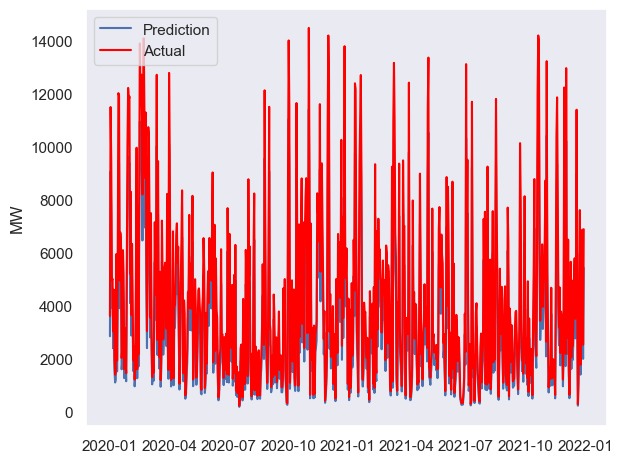

In [97]:
plt.plot(df_final['Predictions'],label='Prediction')
plt.plot(df_final['Actuals'], color='red',label='Actual')

plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

Результаты очень хорошие (видно по метрикам и графику), но они основаны на всем наборе данных — то есть модель обучается на всем наборе данных, а затем прогнозируется на том же наборе данных, который уже использовался для обучения, поэтому  результаты хорошие.

Следующий шаг — прогноз на следующие 365 дней. Для этого я создам 3 группы обучающих и тестовых данных.¶
Весь набор данных за вычетом последних 29 дней в качестве тестового набора.
80% данных в качестве обучающих, а затем 29 дней после этого в качестве тестовых
Две трети данных в качестве обучающих, а затем 29 дней после этого в качестве тестовых, а затем сравните результаты.

Определим количество наблюдений  — 730

In [106]:
len(df_daily)

730

In [108]:
train, test = df_daily[0:700], df_daily[701:]
len(train), len(test)

(700, 29)

In [110]:
# использовать auto_arima  на обучающих данных
model=pm.auto_arima(train,start_p=0,d=0,start_q=0,
          max_p=15,max_q=5, 
          start_P=0,D=0, start_Q=0, 
          max_P=8, max_Q=8, 
          m=12, seasonal=True, stationary=True,
          error_action='warn',trace=True,
          supress_warnings=True,stepwise=True,
          random_state=20,n_fits=100)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=13284.622, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=13141.320, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=13172.386, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=13984.189, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=13140.742, Time=0.01 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=13141.012, Time=0.17 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=13143.009, Time=0.41 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=13142.308, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=13142.484, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=13171.957, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=13144.270, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=13295.378, Time=0.03 sec

Best model:  ARIMA(1,0,0)(0,0,0)[12] intercept
Total fit time: 1.203 seconds


In [111]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  700
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -6567.371
Date:                Tue, 29 Apr 2025   AIC                          13140.742
Time:                        23:49:26   BIC                          13154.395
Sample:                    01-01-2020   HQIC                         13146.020
                         - 11-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2367.1501    229.586     10.310      0.000    1917.169    2817.131
ar.L1          0.4356      0.032     13.756      0.000       0.374       0.498
sigma2      8.262e+06   4.73e+05     17.454      0.000    7.33e+06    9.19e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               139.31
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                             1.00
Prob(H) (two-sided):                  1.00   Kurtosis:                         3.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [114]:
# Set up the SARIMA model with values as above
p = 1
d = 0
q = 0
P = 3
D = 0
Q = 0
m = 12

model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m), dynamic=True)
model_fit = model.fit(disp=0) # disp=0 so no display
    
test_pred = model_fit.predict(start=1, end=len(test))

In [115]:
test_pred.index = test.index

In [118]:
df_final = pd.DataFrame(data={'Predictions':test_pred, 'Actuals':test })  
df_final.head()
# use auto_arima on the training data alone - not surpisingly with only a small amount of reduced training data the results are the same

,Predictions,Actuals
dt,,
2021-12-02,2074.322273,2169.053438
2021-12-03,6623.193879,12972.197917
2021-12-04,5451.195914,3516.331250
2021-12-05,2858.171314,2768.986146
2021-12-06,2897.389452,6491.639792


In [120]:
print('The Coefficient of determination (R-squared) = {:.2f}'.format(r2_score(df_final['Actuals'],df_final['Predictions'])))
print('The mean absolute error (MAE)                = {:.2f}'.format(mean_absolute_error(df_final['Actuals'],df_final['Predictions'])))
print('The Mean absolute percentage error (MAPE)    = {:.2f}'.format(mean_absolute_percentage_error(df_final['Actuals'],df_final['Predictions'])))   

The Coefficient of determination (R-squared) = -0.14
The mean absolute error (MAE)                = 2344.29
The Mean absolute percentage error (MAPE)    = 0.77


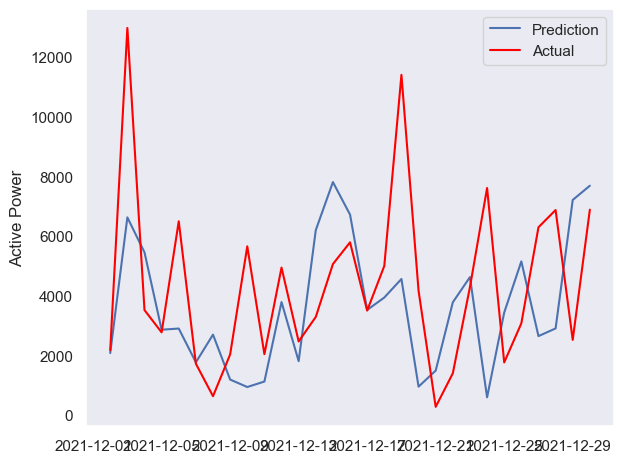

In [122]:
plt.plot(df_final['Predictions'],label='Prediction')
plt.plot(df_final['Actuals'], color='red',label='Actual')

plt.ylabel('Active Power')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

__График прогнозируемых и фактических значений за последние 365 дней набора данных__

In [125]:
train, test = df_daily[0:364], df_daily[395:]

In [127]:
#повторяем шаги
model=pm.auto_arima(train,start_p=0,d=0,start_q=0,
          max_p=15,max_q=5, 
          start_P=0,D=0, start_Q=0, 
          max_P=8, max_Q=8, 
          m=12, seasonal=True, stationary=True,
          error_action='warn',trace=True,
          supress_warnings=True,stepwise=True,
          random_state=20,n_fits=100)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=6928.750, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=6843.187, Time=0.22 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=6861.666, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=7308.692, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=6843.165, Time=0.00 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=6842.753, Time=0.07 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=6844.746, Time=0.24 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=6844.635, Time=0.25 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=6846.631, Time=0.78 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=6924.781, Time=0.05 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=6843.632, Time=0.15 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=6843.587, Time=0.12 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=6845.389, Time=0.26 sec
 ARIMA(1,0,0)(0,0,1)[12]             : AIC=6916.520, Time=0.10 sec

Best model:  ARIMA

In [128]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  364
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 12)   Log Likelihood               -3417.376
Date:                              Tue, 29 Apr 2025   AIC                           6842.753
Time:                                      23:49:37   BIC                           6858.341
Sample:                                  01-01-2020   HQIC                          6848.948
                                       - 12-29-2020                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2396.4580    341.051      7.027      0.000    1728.010    3064.906
ar.L1          0.4597      0.046     10.072      0.000       0.370       0.549
ma.S.L12       0.0857      0.053      1.612      0.107      -0.019       0.190
sigma2      8.431e+06   6.78e+05     12.435      0.000     7.1e+06    9.76e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):                41.20
Prob(Q):                              0.57   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.79
Prob(H) (two-sided):                  0.95   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [130]:
# Set up the SARIMA model with values as above
p = 1
d = 0
q = 0
P = 0
D = 0
Q = 0
m = 12

model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m))
model_fit = model.fit(disp=0) # disp=0 so no display
    
test_pred = model_fit.predict(start=1, end=len(test))

In [133]:
test_pred.index = test.index

In [135]:
df_final = pd.DataFrame(data={'Predictions':test_pred, 'Actuals':test})  
df_final.head()

,Predictions,Actuals
dt,,
2021-01-30,2919.794494,2029.598125
2021-01-31,9326.273290,2777.022396
2021-02-01,7672.120931,905.306354
2021-02-02,4013.795864,2090.146458
2021-02-03,4059.747290,439.823646


In [137]:
print('The Coefficient of determination (R-squared) = {:.2f}'.format(r2_score(df_final['Actuals'],df_final['Predictions'])))
print('The mean absolute error (MAE)                = {:.2f}'.format(mean_absolute_error(df_final['Actuals'],df_final['Predictions'])))
print('The RMSE error (RMSE)                        = {:.2f}'.format(mean_squared_error(df_final['Actuals'],df_final['Predictions'],squared=False)))
print('The Mean absolute percentage error (MAPE)    = {:.2f}'.format(mean_absolute_percentage_error(df_final['Actuals'],df_final['Predictions'])))  

The Coefficient of determination (R-squared) = -0.83
The mean absolute error (MAE)                = 3035.81
The RMSE error (RMSE)                        = 4067.25
The Mean absolute percentage error (MAPE)    = 1.34


График, использующий 80% набора данных для обучения, чтобы предсказать последующие 365 дней.

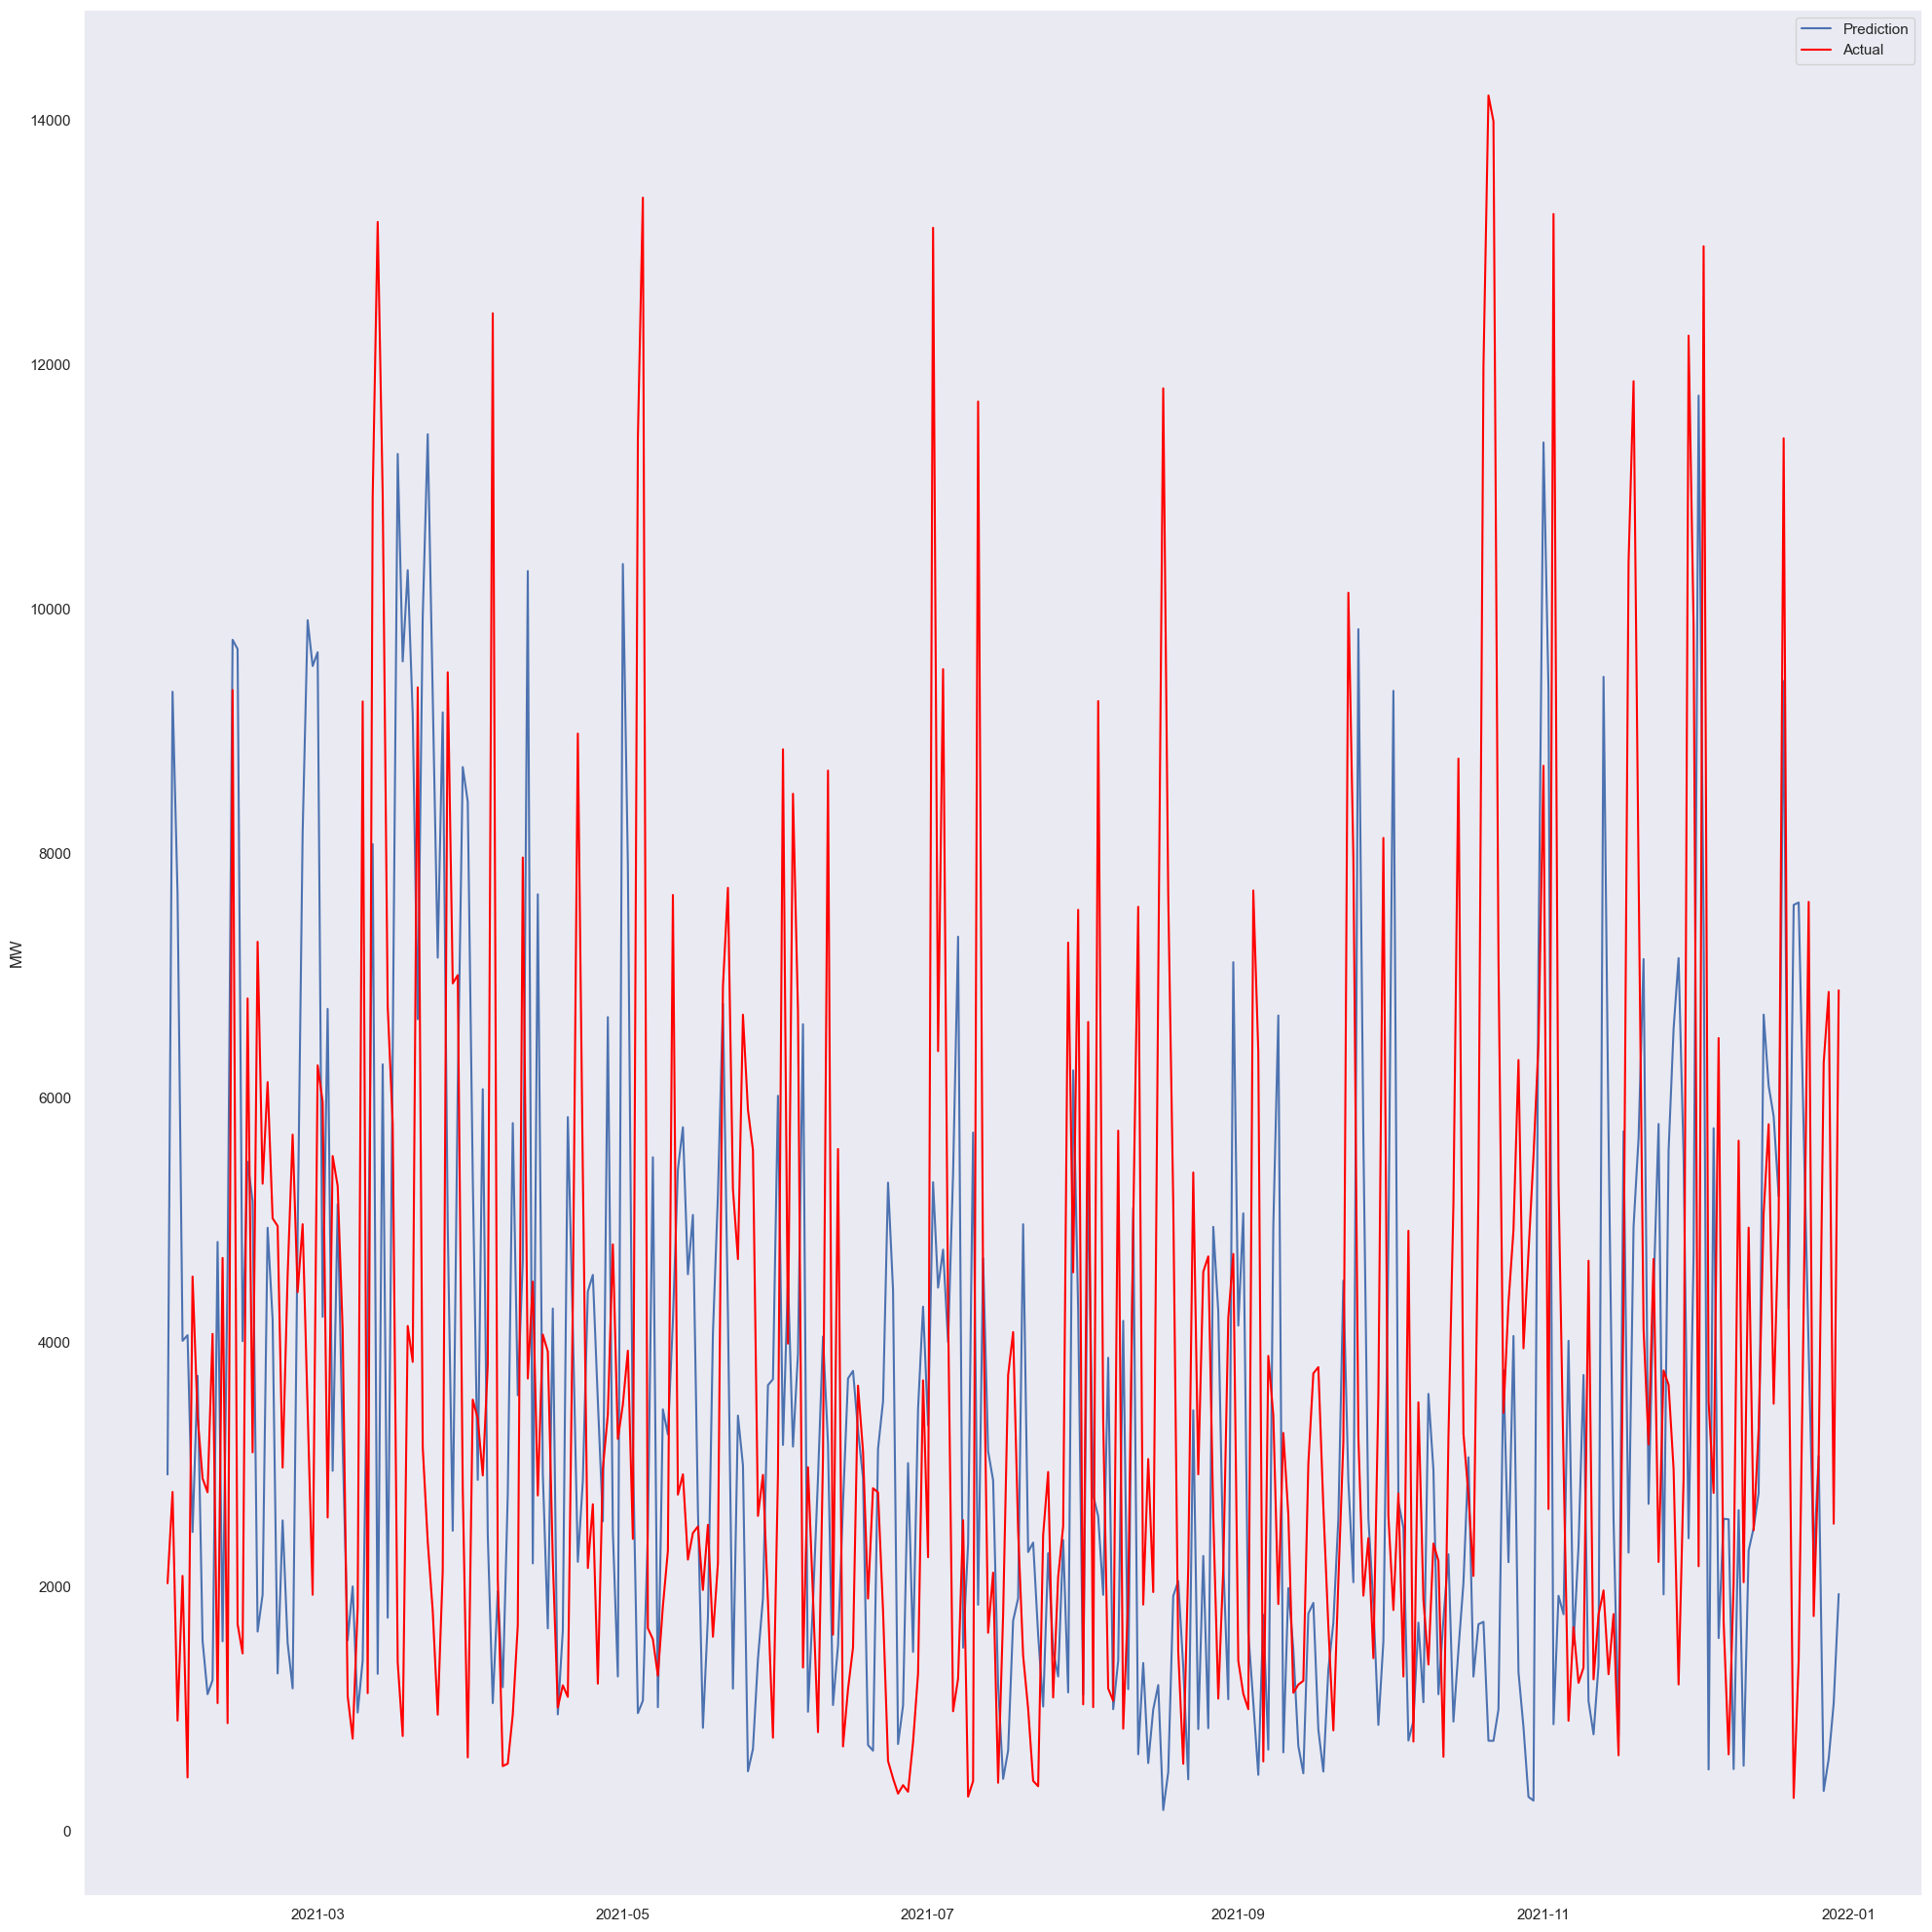

In [148]:
plt.figure(figsize=(20,20))
plt.plot(df_final['Predictions'],label='Prediction')
plt.plot(df_final['Actuals'], color='red',label='Actual')

plt.ylabel('MW')
plt.legend()
plt.tight_layout()
#plt.figure(figsize=(20,20))
plt.grid()
plt.show()

In [ ]:
Для исследования данные брались за 2 последних года. Временной ряд стационарный, поэтому трансформации не вынолнялись

In [ ]:
Для поиска лучших параметров была использована вся выборка. И получены следующие результаты:

In [ ]:
The Coefficient of determination (R-squared) = 0.88
The mean absolute error (MAE)                = 891.42
The RMSE error (RMSE)                        = 1118.22
The Mean absolute percentage error (MAPE)    = 0.21

In [ ]:
При выполнении прогноза получены следующие метрики:

In [ ]:
The Coefficient of determination (R-squared) = -0.83
The mean absolute error (MAE)                = 3035.81
The RMSE error (RMSE)                        = 4067.25
The Mean absolute percentage error (MAPE)    = 1.34

In [ ]:
Коэффициент детерминации стал отрицательным (возможно причина в слишком маленькой выборке или переобучении)
MAE, MAPE и RMSE также увеличились. Метрики показывают, что прогноз не достоверный, слишком большие отклонения от фактическтх значений.
Это можно также видеть и на графике предсказаний на 365 дней.